In [28]:
import matplotlib.pyplot as plt
# Importing required libraries
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import torch
from torchvision import datasets, transforms
import torchvision
from torch.utils.data import DataLoader
from PIL import Image

In [29]:
# Importing images (from a folder containing both good and faulty images)
path = '/Users/dcac/Data/computer_vision/images_anomaly_detection/bottle_mixed/'
# path = '/Users/dcac/Data/computer_vision/images_anomaly_detection/metal_nut_mixed/'

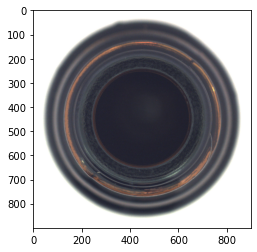

In [30]:
img = Image.open(path+"0_good/000.png")
plt.imshow(img)

In [22]:
# Transformations (e.g., cropping and normalization) required by torchvision pretrained models
transformations = transforms.Compose([transforms.RandomResizedCrop(224),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

1. `transforms.RandomResizedCrop(224)`: This transformation resizes the image to a square of size 224x224 pixels. It also performs a random crop, which helps with data augmentation and ensures that the network learns to recognize objects from different parts of the image.
2. `transforms.RandomHorizontalFlip()`: This transformation randomly flips the image horizontally with a probability of 0.5. It is another form of data augmentation that helps the model generalize better by introducing variations of the original image.
3. `transforms.ToTensor()`: This transformation converts the image into a PyTorch tensor. It changes the image representation from the original format (PIL image) to a tensor that can be processed by neural networks.
4. `transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])`: This transformation normalizes the image tensor by subtracting the mean values `[0.485, 0.456, 0.406]` from each channel and dividing by the standard deviation values `[0.229, 0.224, 0.225]`. Normalization helps to standardize the input data and improve the convergence and performance of the neural network.

In [31]:
transformations = transforms.Compose([transforms.Resize((224, 224)),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [32]:
# Creating a data loader for torch model
dataset = datasets.ImageFolder(path, transform=transformations)
train_loader = DataLoader(dataset, batch_size=len(dataset), shuffle=True)
images, labels = next(iter(train_loader))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


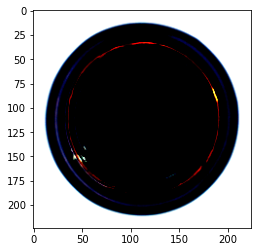

In [33]:
plt.imshow(images[0].permute(1, 2, 0))

In [34]:
# Feature extractor: removing last layer from pretrained resnet
model = torchvision.models.resnet18(pretrained=True)
new_model = torch.nn.Sequential(*(list(model.children())[:-1]))
print(new_model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [35]:
# Getting the extracted features
output = new_model(images)
output = output.reshape(-1, 512)

In [36]:
# Further reducing the dimensionality from 512 to 100 (retaining 90% of the total explained variance)
preprocessed_features = pd.DataFrame(output.cpu().detach().numpy())
pca = PCA(n_components=100, random_state=42)  # 100 PCs = 90% of explained variance
pca.fit(preprocessed_features)
preprocessed_features = pd.DataFrame(pca.transform(preprocessed_features))

In [37]:
# Exporting labeled csv to train a classification model
multiclass_y = labels.cpu().detach().numpy()
preprocessed_features["y"] = multiclass_y
binary_y = np.where(multiclass_y > 0, 1, multiclass_y)
preprocessed_features["y"] = binary_y
preprocessed_features.to_csv("preprocessed_features_nocrop_bottles.csv", index=False)